In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

from methylseqnet.dataset import MultiMethylDataset
from methylseqnet_repro.paths import preprocessed_datasets, annotations
from methylseqnet.annotations import fetch_tss_from_gtf, load_annotated_bed_rows

In [3]:
dataset_path = preprocessed_datasets / "atlas" / "fold0.h5"
gtf = annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"
motifs_bedgz = annotations / "hg38.archetype_motifs.v1.0.bed.gz"
dataset = MultiMethylDataset(dataset_path)

torch.Size([1, 42, 3, 524288])
torch.Size([1, 4, 524288])
torch.Size([1, 63, 4096])
6 170905
[{'chrom': 'chr4', 'tss': 82373991, 'threeprime': 82352498, 'strand': '-', 'gene_id': 'ENSG00000138668.21', 'gene_name': 'HNRNPD', 'transcript_id': 'ENST00000313899.12', 'transcript_type': 'protein_coding', 'canonical': True}, {'chrom': 'chr4', 'tss': 82430462, 'threeprime': 82422569, 'strand': '-', 'gene_id': 'ENSG00000152795.19', 'gene_name': 'HNRNPDL', 'transcript_id': 'ENST00000295470.10', 'transcript_type': 'protein_coding', 'canonical': True}, {'chrom': 'chr4', 'tss': 82430590, 'threeprime': 82461177, 'strand': '+', 'gene_id': 'ENSG00000145293.18', 'gene_name': 'ENOPH1', 'transcript_id': 'ENST00000273920.8', 'transcript_type': 'protein_coding', 'canonical': True}, {'chrom': 'chr4', 'tss': 82561988, 'threeprime': 82483176, 'strand': '-', 'gene_id': 'ENSG00000249242.8', 'gene_name': 'TMEM150C', 'transcript_id': 'ENST00000449862.7', 'transcript_type': 'protein_coding', 'canonical': True}, {'

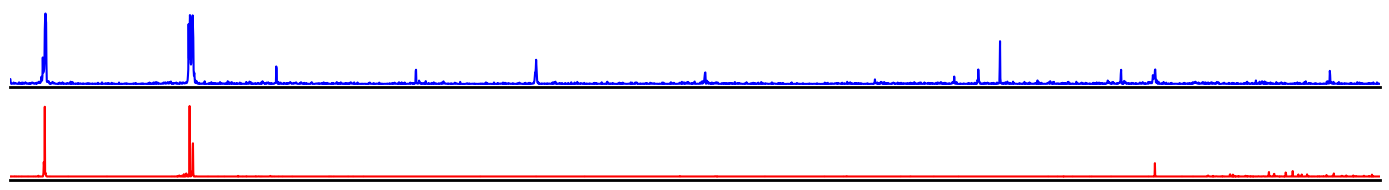

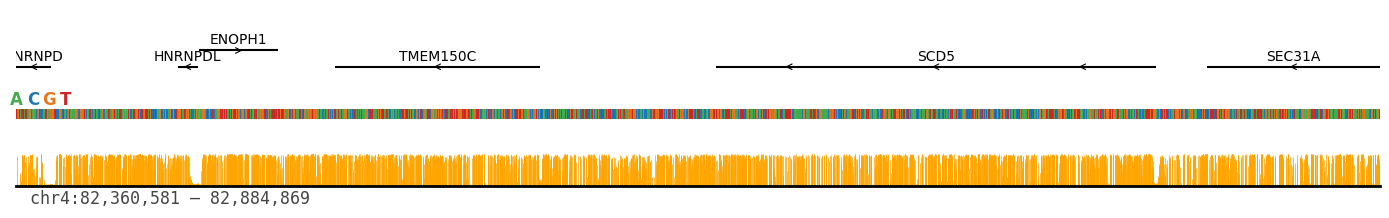

In [57]:
def plot_conditioning(tensor, coords=None, ax=None, chromosome=None):
    """
    tensor: numpy array or torch tensor of shape (3, 524288)
    """
    if hasattr(tensor, 'detach'):
        data = tensor.detach().cpu().numpy()
    else:
        data = np.array(tensor)

    mask = data[2, :] > 0
    indices = np.where(mask)[0]
    
    if len(indices) == 0:
        print("No points found where the 3rd dimension is > 0.")
        return

    heights = data[0, indices] + data[1, indices]
    coordinates = coords[indices] if coords is not None else indices

    segments = [((coord, 0), (coord, h)) for coord, h in zip(coordinates, heights)]
    lc = LineCollection(segments, colors='orange', linewidths=0.5, alpha=0.7)

    if ax is None:
        plt.figure(figsize=(15, 5))
        ax = plt.gca()

    ax.add_collection(lc)

    if coords is not None:
        xmin, xmax = coords.min(), coords.max() + 1
        ax.set_xlim(xmin, xmax)
    else:
        xmin, xmax = 0, data.shape[1]
        ax.set_xlim(xmin, xmax)

    ax.set_ylim(0, 1)

    # Remove all spines except bottom
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_linewidth(2)

    # Bold x-axis line only, no ticks or labels
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    # Coordinate range label in bottom-left corner
    label = f"{f'{chromosome}:' if chromosome is not None else ''}{int(xmin):,} – {int(xmax):,}"
    ax.text(0.01, -0.12, label, transform=ax.transAxes,
            fontsize=12, va='top', ha='left', color='#444444',
            fontfamily='monospace')
def plot_sequence_texture(sequence, coords=None, ax=None, plt_start=0, plt_end=None):
    """
    sequence: one-hot tensor/array of shape (4, L) — channels are A, C, G, T
    Renders a compressed colorful strip suggesting DNA sequence.
    """
    if hasattr(sequence, 'detach'):
        seq = sequence.detach().cpu().numpy()
    else:
        seq = np.array(sequence)

    if plt_end is None:
        plt_end = seq.shape[1]

    seq = seq[:, plt_start:plt_end]
    L = seq.shape[1]

    # Downsample to ~2000 columns for rendering
    n_cols = 2000
    step = max(1, L // n_cols)
    seq_ds = seq[:, ::step]

    base_colors = np.array([
        [0.27, 0.67, 0.31],  # A - green
        [0.12, 0.47, 0.71],  # C - blue
        [0.89, 0.47, 0.13],  # G - orange
        [0.80, 0.15, 0.15],  # T - red
    ])

    # Build RGBA image: stack bases as colored segments per column
    n_bases, n_cols_ds = seq_ds.shape
    img = np.zeros((4, n_cols_ds, 4))  # (rows=4 bases, cols, RGBA)
    for b in range(4):
        img[b, :, :3] = base_colors[b]
        img[b, :, 3] = seq_ds[b, :]  # alpha = weight of that base

    # Composite onto white
    composite = np.ones((4, n_cols_ds, 3))
    for b in range(4):
        alpha = img[b, :, 3][np.newaxis, :, np.newaxis]
        composite = composite * (1 - alpha) + img[b, :, :3][np.newaxis] * alpha

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 0.3))

    xmin = coords[plt_start] if coords is not None else plt_start
    xmax = coords[plt_end - 1] if coords is not None else plt_end

    ax.imshow(composite, aspect='auto', extent=[xmin, xmax, 0, 1],
              interpolation='nearest')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, 1)
    ax.axis('off')
    base_labels = ['A', 'C', 'G', 'T']
    for i, (label, color) in enumerate(zip(base_labels, base_colors)):
        ax.text(xmin + i * (xmax - xmin) * 0.012 + 0.03, 1.1, label, transform=ax.transData,
                fontsize=12, fontweight='bold', va='bottom', ha='center',
                color=color)
def plot_transcripts(transcript_list, plot_start_coord, plot_end_coord, ax_tx):
    # Assign rows based on actual overlap
    rows = []  # each entry is the x_end of the last transcript placed in that row

    placed = []
    for tx in transcript_list:
        tss = tx["tss"]
        end = tx["threeprime"]
        strand = tx["strand"]
        name = tx["gene_name"]
        tx_start = min(tss, end)
        tx_end = max(tss, end)

        if tx_end < plot_start_coord or tx_start > plot_end_coord:
            continue

        # Clip to plot window
        draw_start = max(tx_start, plot_start_coord)
        draw_end = min(tx_end, plot_end_coord)

        # Find first row with no overlap (with small padding)
        pad = (plot_end_coord - plot_start_coord) * 0.01
        assigned_row = None
        for r, row_end in enumerate(rows):
            if draw_start > row_end + pad:
                rows[r] = draw_end
                assigned_row = r
                break
        if assigned_row is None:
            assigned_row = len(rows)
            rows.append(draw_end)

        placed.append((tx_start, tx_end, draw_start, draw_end, strand, name, assigned_row))

    if not placed:
        return

    n_rows = len(rows)
    row_height = 1.0 / max(n_rows, 1)

    for tx_start, tx_end, draw_start, draw_end, strand, name, row in placed:
        y = row * row_height + row_height * 0.5

        # Gene body line
        ax_tx.plot([draw_start, draw_end], [y, y], color="black", linewidth=1.5,
                   solid_capstyle="butt")

        # Arrow(s) along the body to show strand direction
        span = draw_end - draw_start
        n_arrows = max(1, int(span / ((plot_end_coord - plot_start_coord) * 0.1)))
        arrow_positions = [draw_start + span * (k + 0.5) / n_arrows for k in range(n_arrows)]
        dx = (plot_end_coord - plot_start_coord) * 0.005
        if strand == "-":
            dx = -dx
        for ax_pos in arrow_positions:
            ax_tx.annotate("", xy=(ax_pos + dx, y), xytext=(ax_pos, y),
                           arrowprops=dict(arrowstyle="->", color="black", lw=0.8))

        # Label above the line
        mid = (draw_start + draw_end) / 2
        ax_tx.text(mid, y + row_height * 0.2, name, ha="center", va="bottom", fontsize=10,
                   clip_on=True)

    ax_tx.set_xlim(plot_start_coord, plot_end_coord)
    ax_tx.set_ylim(0, max(n_rows, 1))
    ax_tx.axis("off")
    # plt.grid(True, linestyle='--', alpha=0.3)
def coverage_array(regions, chrom, window_start, window_end):
    """
    regions: list of dicts (or tuples) with chrom/start/end
    Returns a numpy array of coverage counts over [window_start, window_end).
    """
    length = window_end - window_start
    cov = np.zeros(length, dtype=np.int32)
    for r in regions:
        if r[0] != chrom:
            continue
        lo = max(int(r[1]), window_start) - window_start
        hi = min(int(r[2]), window_end) - window_start
        if lo < hi:
            cov[lo:hi] += 1
    return cov
plt_start = 0
plt_end = 524288
target_channels = [32,33]
colors = ["blue", "red"]
num_plots = 1
for sample_idx, sample in enumerate(dataset):
    print(sample["conditioning_state"].shape)
    print(sample["sequence"].shape)
    print(sample["target"].shape)
    region_str = sample["specifier"].split("|")[0]
    chromosome = region_str.split(":")[0]
    region_start = int(region_str.split(":")[1].split("-")[0])
    region_end = int(region_str.split(":")[1].split("-")[1])
    transcript_list = fetch_tss_from_gtf(
        gtf,
        fetch_params = (chromosome,
        region_start,
        region_end)
    )
    tf_binding_list = load_annotated_bed_rows(
        motifs_bedgz,
        fetch_params = (chromosome,
        region_start,
        region_end)
    )
    tf_binding_cov = coverage_array(tf_binding_list, chromosome, region_start, region_end)
    input_coords = np.arange(region_start, region_end)
    output_coords = np.arange(region_start, region_end, 128)
    print(len(transcript_list), len(tf_binding_list))
    print(transcript_list)
    tracks_fig, tracks_axs = plt.subplots(len(target_channels), 1, figsize=(14, (len(target_channels))))
    
    for target_idx, target_channel in enumerate(target_channels):
        tracks_axs[target_idx].plot(output_coords[plt_start//128:plt_end//128], (sample["target"][0,target_channel,plt_start//128:plt_end//128].cpu().numpy()), color=colors[target_idx], linewidth=1.5)
        tracks_axs[target_idx].set_xlim(region_start + plt_start, region_start + plt_end)
        tracks_axs[target_idx].spines['top'].set_visible(False)
        tracks_axs[target_idx].spines['right'].set_visible(False)
        tracks_axs[target_idx].spines['left'].set_visible(False)
        tracks_axs[target_idx].spines['bottom'].set_linewidth(2)
        tracks_axs[target_idx].tick_params(axis='both', which='both', bottom=False, labelbottom=False, left=False, labelleft=False)

    inputs_fig, inputs_axs = plt.subplots(3, 1, figsize=(14, 2.3), gridspec_kw={'height_ratios': [2, 0.3, 1]})
    plot_sequence_texture(sample["sequence"][0,:,:], coords=input_coords, ax=inputs_axs[-2], plt_start=plt_start, plt_end=plt_end)
    plot_conditioning(sample["conditioning_state"][0,0,:,plt_start:plt_end],coords=input_coords[plt_start:plt_end],ax=inputs_axs[-1],chromosome=chromosome)
    # Transcript subplot
    ax_tx = inputs_axs[-3]
    plot_start_coord = region_start + plt_start
    plot_end_coord = region_start + plt_end
    plot_transcripts(transcript_list, plot_start_coord, plot_end_coord, ax_tx)

    tracks_fig.tight_layout()
    inputs_fig.tight_layout()
    tracks_fix.savefig(f"sample_{sample_idx}_tracks_1000dpi.png", dpi=1000)
    inputs_fig.savefig(f"sample_{sample_idx}_inputs_1000dpi.png", dpi=1000)

    if sample_idx >= num_plots - 1:
        break